<a href="https://colab.research.google.com/github/jngadiub/ML_course_Pavia_23/blob/main/pytorch_intro.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Introduction to Pytorch

Adapted from official [Pytorch tutorial](https://pytorch.org/tutorials/beginner/basics/intro.html) for dealing with PyTorch tensors, datasets, building neural networks etc., also has an accompanying video series.

## Tensors

Tensors are a specialized data structure that are very similar to NumPy `ndarrays`. In PyTorch, we use tensors to encode the inputs and outputs of a model, as well as the model’s parameters. Tensors are also optimized for automatic differentiation.

In [1]:
import torch
import numpy as np

### Initializing a Tensor

Tensors can be initialized in various ways. Take a look at the following examples:

**Directly from data**

Tensors can be created directly from data. The data type is automatically inferred.

In [2]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

**From a NumPy array**

Tensors can be created from NumPy arrays (and vice versa).

In [3]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

**From another tensor**

The new tensor retains the properties (shape, datatype) of the argument tensor, unless explicitly overridden.

In [4]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.5139, 0.5446],
        [0.9411, 0.1361]]) 



**With random or constant values**

`shape` is a tuple of tensor dimensions. In the functions below, it determines the dimensionality of the output tensor.

In [5]:
shape = (2,3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.6947, 0.1521, 0.3866],
        [0.9961, 0.9428, 0.9163]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Attributes of a Tensor

Tensor attributes describe their shape, datatype, and the device on which they are stored.

In [6]:
tensor = torch.rand(3,4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Operations on Tensors

Over 100 tensor operations, including arithmetic, linear algebra, matrix manipulation (transposing, indexing, slicing), sampling and more are comprehensively described [here](https://pytorch.org/docs/stable/torch.html).

Each of these operations can be run on the GPU. By default, tensors are created on the CPU. We need to explicitly move tensors to the GPU using `.to` method (after checking for GPU availability).

In [7]:
# We move our tensor to the GPU if available
if torch.cuda.is_available():
    print("Found GPU")
    tensor = tensor.to("cuda")

Found GPU


**Standard numpy-like indexing and slicing**

In [8]:
tensor = torch.rand(4, 4)
print(tensor)
print(f"First row: {tensor[0,:]}")
print(f"First column: {tensor[:,0]}")
print(f"Last column: {tensor[:,-1]}")
tensor[:,1] = 0
print(tensor)

tensor([[4.3039e-01, 5.7965e-01, 6.6455e-01, 2.8660e-01],
        [9.5592e-01, 2.5046e-04, 4.7402e-01, 5.2267e-01],
        [8.0708e-01, 4.0730e-01, 9.9251e-01, 6.9886e-01],
        [7.2400e-01, 8.9829e-01, 9.4619e-01, 4.1970e-01]])
First row: tensor([0.4304, 0.5796, 0.6646, 0.2866])
First column: tensor([0.4304, 0.9559, 0.8071, 0.7240])
Last column: tensor([0.2866, 0.5227, 0.6989, 0.4197])
tensor([[0.4304, 0.0000, 0.6646, 0.2866],
        [0.9559, 0.0000, 0.4740, 0.5227],
        [0.8071, 0.0000, 0.9925, 0.6989],
        [0.7240, 0.0000, 0.9462, 0.4197]])


**Joining tensors**

You can use `torch.cat` to concatenate a sequence of tensors along a given dimension.

In [9]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1.shape)
print(t1)

torch.Size([4, 12])
tensor([[0.4304, 0.0000, 0.6646, 0.2866, 0.4304, 0.0000, 0.6646, 0.2866, 0.4304,
         0.0000, 0.6646, 0.2866],
        [0.9559, 0.0000, 0.4740, 0.5227, 0.9559, 0.0000, 0.4740, 0.5227, 0.9559,
         0.0000, 0.4740, 0.5227],
        [0.8071, 0.0000, 0.9925, 0.6989, 0.8071, 0.0000, 0.9925, 0.6989, 0.8071,
         0.0000, 0.9925, 0.6989],
        [0.7240, 0.0000, 0.9462, 0.4197, 0.7240, 0.0000, 0.9462, 0.4197, 0.7240,
         0.0000, 0.9462, 0.4197]])


**Arithmetic operations**

In [10]:
# This computes the matrix multiplication between two tensors. y1, y2, y3 will have the same value
# ``tensor.T`` returns the transpose of a tensor
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)

y3 = torch.rand_like(y1)
torch.matmul(tensor, tensor.T, out=y3)


# This computes the element-wise product. z1, z2, z3 will have the same value
z1 = tensor * tensor
z2 = tensor.mul(tensor)

z3 = torch.rand_like(tensor)
torch.mul(tensor, tensor, out=z3)

tensor([[0.1852, 0.0000, 0.4416, 0.0821],
        [0.9138, 0.0000, 0.2247, 0.2732],
        [0.6514, 0.0000, 0.9851, 0.4884],
        [0.5242, 0.0000, 0.8953, 0.1761]])

**Single-element tensors**

If you have a one-element tensor, for example by aggregating all values of a tensor into one value, you can convert it to a Python numerical value using `item()`:

In [11]:
agg = tensor.sum()
agg_item = agg.item()
print(agg_item, type(agg_item))

7.922476291656494 <class 'float'>


**In-place operations**

Operations that store the result into the operand are called in-place. They are denoted by a `_` suffix. For example: `x.copy_(y)`, `x.t_()`, will change `x`.

In [12]:
print(f"{tensor} \n")
tensor.add_(5)
print(tensor)

tensor([[0.4304, 0.0000, 0.6646, 0.2866],
        [0.9559, 0.0000, 0.4740, 0.5227],
        [0.8071, 0.0000, 0.9925, 0.6989],
        [0.7240, 0.0000, 0.9462, 0.4197]]) 

tensor([[5.4304, 5.0000, 5.6646, 5.2866],
        [5.9559, 5.0000, 5.4740, 5.5227],
        [5.8071, 5.0000, 5.9925, 5.6989],
        [5.7240, 5.0000, 5.9462, 5.4197]])


### Bridge with NumPy

Tensors on the CPU and NumPy arrays can share their underlying memory locations, and changing one will change the other.

**Tensor to NumPy array**

In [13]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


A change in the tensor reflects in the NumPy array.

In [14]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


**NumPy array to Tensor**

In [15]:
n = np.ones(5)
t = torch.from_numpy(n)

Changes in the NumPy array reflects in the tensor.

In [16]:
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


## Working with data

PyTorch has [two primitives to work with data](https://pytorch.org/docs/stable/data.html): `torch.utils.data.DataLoader` and `torch.utils.data.Dataset`:
* **Dataset** stores the samples and their corresponding labels;
* **DataLoader** wraps an iterable around the `Dataset` to enable easy access to the samples.

PyTorch domain libraries provide a number of pre-loaded datasets (such as FashionMNIST) that subclass `torch.utils.data.Dataset` and implement functions specific to the particular data. They can be used to prototype and benchmark your model. You can find them here: [Image Datasets](https://pytorch.org/vision/stable/datasets.html), [Text Datasets](https://pytorch.org/text/stable/datasets.html), and [Audio Datasets](https://pytorch.org/audio/stable/datasets.html).

### Loading a Dataset

Here is an example of how to load the [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) from [TorchVision](https://pytorch.org/vision/stable/datasets.html). Fashion-MNIST is a dataset of Zalando’s article images consisting of 60,000 training examples and 10,000 test examples. Each example comprises a 28×28 grayscale image and an associated label from one of 10 classes.

We load the [FashionMNIST Dataset](https://pytorch.org/vision/stable/datasets.html#fashion-mnist) with the following parameters:

* `root` is the path where the train/test data is stored;
* `train` specifies training or test dataset;
* `download=True` downloads the data from the internet if it’s not available at `root`;
* `transform` and `target_transform` specify the feature and label transformations.


In [17]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor()
)

  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



### Iterating and Visualizing the Dataset

We can index `Datasets` manually like a list: `training_data[index]`. We use `matplotlib` to visualize some samples in our training data.

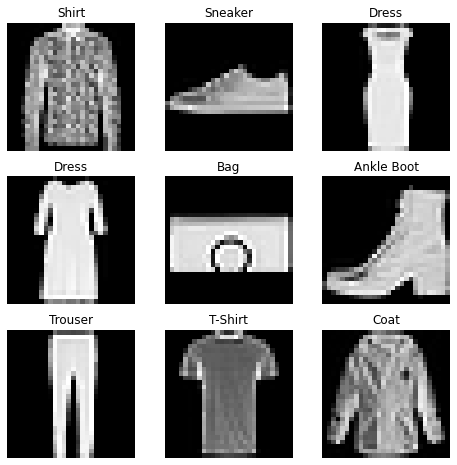

In [18]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### Creating a Custom Dataset for your files

A custom `Dataset` class must implement three functions: `__init__`, `__len__`, and `__getitem__`. Take a look at this implementation; the FashionMNIST images are stored in a directory `img_dir`, and their labels are stored separately in a CSV file `annotations_file`.

In the next sections, we’ll break down what’s happening in each of these functions.

In [19]:
import os
import pandas as pd
from torchvision.io import read_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label = self.img_labels.iloc[idx, 1]
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

**`__init_`**

The `__init__` function is run once when instantiating the `Dataset` object. We initialize the directory containing the images, the annotations file, and both transforms (covered in more detail in the next section).

The `labels.csv` file looks like:

```
tshirt1.jpg, 0
tshirt2.jpg, 0
......
ankleboot999.jpg, 9
```

**`__len__`**

The `__len__` function returns the number of samples in our dataset.

**`__getitem__`**

The `__getitem__` function loads and returns a sample from the dataset at the given index `idx`. Based on the index, it identifies the image’s location on disk, converts that to a tensor using `read_image`, retrieves the corresponding label from the csv data in `self.img_labels`, calls the `transform` functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

### Preparing your data for training with DataLoaders

The `Dataset` retrieves our dataset’s features and labels one sample at a time. While training a model, we typically want to pass samples in *minibatches*, reshuffle the data at every epoch to reduce model overfitting, and use Python’s multiprocessing to speed up data retrieval.

`DataLoader` is an iterable that abstracts this complexity for us in an easy API.

In [20]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

### Iterate through the DataLoader

We have loaded that dataset into the `DataLoader` and can iterate through the dataset as needed. Each iteration below returns a batch of `train_features` and `train_labels` (containing `batch_size=64` features and labels respectively). Because we specified `shuffle=True`, after we iterate over all batches the data is shuffled (for finer-grained control over the data loading order, take a look at [Samplers](https://pytorch.org/docs/stable/data.html#data-loading-order-and-sampler)).

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


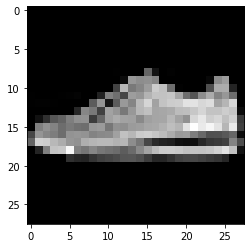

Label: 7


In [21]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze() #Returns a tensor with all the dimensions of input of size 1 removed
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

### Transforms

Data does not always come in its final processed form that is required for training machine learning algorithms. We use **transforms** to perform some manipulation of the data and make it suitable for training.

All TorchVision datasets have two parameters: `transform` to modify the features and `target_transform` to modify the labels - that accept callables containing the transformation logic. The [`torchvision.transforms`](https://pytorch.org/vision/stable/transforms.html) module offers several commonly-used transforms out of the box.

The FashionMNIST features are in Python Imaging Library (PIL) format, and the labels are integers. For training, we need the features as normalized tensors, and the labels as one-hot encoded tensors. To make these transformations, we use `ToTensor` and `Lambda`.

In [22]:
ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))
)

**ToTensor()**

[`ToTensor`](https://pytorch.org/vision/stable/transforms.html#torchvision.transforms.ToTensor) converts a PIL image or NumPy `ndarray` into a `FloatTensor`. and scales the image’s pixel intensity values in the range `[0., 1.]`

**Lambda Transforms**

`Lambda` transforms apply any user-defined lambda function. Here, we define a function to turn the integer into a one-hot encoded tensor. It first creates a zero tensor of size 10 (the number of labels in our dataset) and calls [`scatter_`](https://pytorch.org/docs/stable/generated/torch.Tensor.scatter_.html) which assigns a `value=1` on the index as given by the label `y`.

## Build the Neural Network

Neural networks comprise of layers/modules that perform operations on data. The [torch.nn](https://pytorch.org/docs/stable/nn.html) namespace provides all the building blocks you need to build your own neural network. Every module in PyTorch subclasses the [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html). A neural network is a module itself that consists of other modules (layers). This nested structure allows for building and managing complex architectures easily.

In the following sections, we’ll build a neural network to classify images in the FashionMNIST dataset.


In [23]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms


### Get Device for Training

We want to be able to train our model on a hardware accelerator like the GPU, if it is available. Let’s check to see if [torch.cuda](https://pytorch.org/docs/stable/notes/cuda.html) is available, else we continue to use the CPU.

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


### Define the Class

We define our neural network by subclassing `nn.Module`, and initialize the neural network layers in `__init__`. Every `nn.Module` subclass implements the operations on input data in the `forward` method.

In [25]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

We create an instance of `NeuralNetwork`, and move it to the `device`, and print its structure.

In [27]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


To use the model, we pass it the input data. This executes the model’s `forward`.

Calling the model on the input returns a 2-dimensional tensor with dim=0 corresponding to each output of 10 raw predicted values for each class, and dim=1 corresponding to the individual values of each output. We get the prediction probabilities by passing it through an instance of the `nn.Softmax` module.

In [28]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

Predicted class: tensor([7], device='cuda:0')


### Model Layers

Let’s break down the layers in the FashionMNIST model. To illustrate it, we will take a sample minibatch of 3 images of size 28x28 and see what happens to it as we pass it through the network.

In [29]:
input_image = torch.rand(3,28,28)
print(input_image.size())

torch.Size([3, 28, 28])


**nn.Flatten**

We initialize the [`nn.Flatten`](https://pytorch.org/docs/stable/generated/torch.nn.Flatten.html) layer to convert each 2D 28x28 image into a contiguous array of 784 pixel values (the minibatch dimension (at dim=0) is maintained).



In [31]:
flatten = nn.Flatten()
flat_image = flatten(input_image)
print(flat_image.size())

torch.Size([3, 784])


**nn.Linear**

The [linear layer](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) is a module that applies a linear transformation on the input using its stored weights and biases.

In [32]:
layer1 = nn.Linear(in_features=28*28, out_features=20)
hidden1 = layer1(flat_image)
print(hidden1.size())

torch.Size([3, 20])


**nn.ReLU**

Non-linear activations are what create the complex mappings between the model’s inputs and outputs. They are applied after linear transformations to introduce nonlinearity, helping neural networks learn a wide variety of phenomena.

In this model, we use [`nn.ReLU`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) between our linear layers, but there’s other activations to introduce non-linearity in your model.

In [ ]:
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[-0.5188, -0.0661,  0.0090,  0.1981,  0.5975, -0.2900, -0.0439,  0.5651,
         -0.3160, -0.3220, -0.2128,  0.3450, -0.3802,  0.1047, -0.2765, -0.3682,
         -0.1843,  0.0618,  0.1017, -0.0619],
        [-0.4494, -0.4007, -0.0143,  0.0947,  0.7322,  0.0331,  0.1314,  0.3287,
         -0.0468, -0.4521, -0.2348,  0.1219, -0.0521,  0.1988, -0.3137, -0.2548,
         -0.0635,  0.1714,  0.0321,  0.0971],
        [-0.1494, -0.0366, -0.0059,  0.1665,  0.7180, -0.1233,  0.0222,  0.4589,
         -0.0511, -0.6441, -0.4415,  0.2920, -0.0535, -0.0058, -0.3058, -0.2657,
         -0.1123,  0.2503,  0.0865, -0.0998]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.0000, 0.0000, 0.0090, 0.1981, 0.5975, 0.0000, 0.0000, 0.5651, 0.0000,
         0.0000, 0.0000, 0.3450, 0.0000, 0.1047, 0.0000, 0.0000, 0.0000, 0.0618,
         0.1017, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0947, 0.7322, 0.0331, 0.1314, 0.3287, 0.0000,
         0.0000, 0.0000, 0.1219, 0.0000, 0.1988, 0.00

**nn.Sequential**

[`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) is an ordered container of modules. The data is passed through all the modules in the same order as defined. You can use sequential containers to put together a quick network like `seq_modules`.

In [36]:
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)
print(logits)

tensor([[ 0.1858, -0.1254,  0.1237, -0.2667, -0.1568,  0.0655, -0.1419, -0.1704,
         -0.2920, -0.0764],
        [ 0.3609, -0.2248,  0.0788, -0.2109, -0.2347,  0.0235, -0.0457, -0.1635,
         -0.3721, -0.0199],
        [ 0.3139, -0.1354,  0.0582, -0.3066, -0.1693,  0.0891, -0.1764, -0.2275,
         -0.3102, -0.1160]], grad_fn=<AddmmBackward0>)


**nn.Softmax**

The last linear layer of the neural network returns logits - values in [-infty, infty] - which are passed to the [`nn.Softmax`](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html) module. The logits are scaled to values [0, 1] representing the model’s predicted probabilities for each class. `dim` parameter indicates the dimension along which the values must sum to 1.

In [35]:
softmax = nn.Softmax(dim=1) #softmax is over the columns per each row
pred_probab = softmax(logits)
print(pred_probab)

tensor([[0.1165, 0.0897, 0.1052, 0.1010, 0.0999, 0.1084, 0.0882, 0.0848, 0.1144,
         0.0918],
        [0.1005, 0.0838, 0.1061, 0.0931, 0.0964, 0.1294, 0.1029, 0.0835, 0.1075,
         0.0968],
        [0.1279, 0.0905, 0.0932, 0.0945, 0.0927, 0.1055, 0.0873, 0.0951, 0.1110,
         0.1022]], grad_fn=<SoftmaxBackward0>)


### Model Parameters

Many layers inside a neural network are parameterized, i.e. have associated weights and biases that are optimized during training. Subclassing `nn.Module` automatically tracks all fields defined inside your model object, and makes all parameters accessible using your model’s `parameters()` or `named_parameters()` methods.

In this example, we iterate over each parameter, and print its size and a preview of its values.

In [38]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[ 0.0327,  0.0249,  0.0343,  ...,  0.0012, -0.0176,  0.0218],
        [-0.0202,  0.0074, -0.0331,  ...,  0.0277,  0.0127,  0.0109]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([0.0229, 0.0297], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[-0.0177,  0.0151,  0.0380,  ...,  0.0217, -0.0168,  0.0072],
        [-0.0221,  0.0393, -0.0279,  ...,  0.0299,  0.0292, -0.0246]],
       device='cuda:0', grad_fn=<Slic

## Automatic Differentiation with `torch.autograd`

When training neural networks, the most frequently used algorithm is back propagation. In this algorithm, parameters (model weights) are adjusted according to the gradient of the loss function with respect to the given parameter.

To compute those gradients, PyTorch has a built-in differentiation engine called torch.autograd. It supports automatic computation of gradient for any computational graph.

Consider the simplest one-layer neural network, with input x, parameters w and b, and some loss function. It can be defined in PyTorch in the following manner:

PyTorch offers domain-specific libraries such as [TorchText](https://pytorch.org/text/stable/index.html), [TorchVision](https://pytorch.org/vision/stable/index.html), and [TorchAudio](https://pytorch.org/audio/stable/index.html), all of which include datasets. For this tutorial, we will be using a **TorchVision** dataset.

The `torchvision.datasets` module contains `Dataset` objects for many real-world vision data like *CIFAR*, *COCO* ([full list here](https://pytorch.org/vision/stable/datasets.html)). In this tutorial, we use the **FashionMNIST** dataset. Every TorchVision Dataset includes two arguments: `transform` and `target_transform` to modify the samples and labels respectively.

In [ ]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/train-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to data/FashionMNIST/raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to data/FashionMNIST/raw



In [ ]:
!ls data/FashionMNIST/raw

t10k-images-idx3-ubyte	   train-images-idx3-ubyte
t10k-images-idx3-ubyte.gz  train-images-idx3-ubyte.gz
t10k-labels-idx1-ubyte	   train-labels-idx1-ubyte
t10k-labels-idx1-ubyte.gz  train-labels-idx1-ubyte.gz


We pass the `Dataset` as an argument to `DataLoader`. This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling and multiprocess data loading. Here we define a batch size of `64`, i.e. each element in the dataloader iterable will return a batch of `64` features and labels:

In [ ]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


Read more about [loading data in PyTorch](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html).

### Creating Models

To define a neural network in PyTorch, we create a class that inherits from [nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html). We define the layers of the network in the `__init__` function and specify how data will pass through the network in the forward function. To accelerate operations in the neural network, we move it to the GPU if available.

In [ ]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Read more about [building neural networks in PyTorch](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html).

### Training the model

To train a model, we need a [loss function](https://pytorch.org/docs/stable/nn.html#loss-functions) and an [optimizer](https://pytorch.org/docs/stable/optim.html).

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In a single training loop, the model makes predictions on the training dataset (fed to it in batches), and backpropagates the prediction error to adjust the model’s parameters.

Inside the training loop, optimization happens in three steps:

* `optimizer.zero_grad()` resets the gradients of model parameters -- gradients by default add up, thus to prevent double-counting, we explicitly zero them at each iteration.
* `loss.backward()` backpropagates the prediction loss -- PyTorch deposits the gradients of the loss w.r.t. each parameter.
* `optimizer.step()` adjusts the parameters by the gradients collected in the backward pass.


In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

We also check the model’s performance against the test dataset to ensure it is learning.

In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

The training process is conducted over several iterations (*epochs*). During each epoch, the model learns parameters to make better predictions. We print the model’s *accuracy* and *loss* at each epoch; we’d like to see the accuracy increase and the loss decrease with every epoch.

In [ ]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.302419  [    0/60000]
loss: 2.288648  [ 6400/60000]
loss: 2.268717  [12800/60000]
loss: 2.263657  [19200/60000]
loss: 2.245932  [25600/60000]
loss: 2.209490  [32000/60000]
loss: 2.220448  [38400/60000]
loss: 2.182758  [44800/60000]
loss: 2.184161  [51200/60000]
loss: 2.152155  [57600/60000]
Test Error: 
 Accuracy: 44.4%, Avg loss: 2.143496 

Epoch 2
-------------------------------
loss: 2.158018  [    0/60000]
loss: 2.142599  [ 6400/60000]
loss: 2.087870  [12800/60000]
loss: 2.103604  [19200/60000]
loss: 2.045658  [25600/60000]
loss: 1.981406  [32000/60000]
loss: 2.012322  [38400/60000]
loss: 1.932708  [44800/60000]
loss: 1.944006  [51200/60000]
loss: 1.865317  [57600/60000]
Test Error: 
 Accuracy: 58.2%, Avg loss: 1.863319 

Epoch 3
-------------------------------
loss: 1.901897  [    0/60000]
loss: 1.860665  [ 6400/60000]
loss: 1.755797  [12800/60000]
loss: 1.795324  [19200/60000]
loss: 1.677250  [25600/60000]
loss: 1.634254  [32000/600

Read more about [Training your model](https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html).

### Saving and loading the model

A common way to save a model is to convert the parameters tensors into a `state_dict` object, which is a Python dictionary that maps each layer to its parameter tensor.

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


The process for loading a model includes re-creating the model structure and loading the state dictionary into it.

In [ ]:
model = NeuralNetwork()
model.load_state_dict(torch.load("model.pth"))

<All keys matched successfully>

After loading, the model can be used to make predictions.

In [ ]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"
